# Car Detection in Snow – Main Notebook
**Course:** D7047E Advanced Deep Learning | LTU VT2026  
**Dataset:** [Nordic Vehicle Dataset (NVD)](https://nvd.ltu-ai.dev/)  
**Models:** YOLO26s, RT-DETR, Faster R-CNN

---

This is the single entry-point notebook for the project. It is organised into the following sections:

1. [Environment & Imports](#1-environment--imports)
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis-eda)
3. [Dataset Preparation](#3-dataset-preparation)
4. [Training](#4-training)
   - 4.1 Tiled dataset generation + COCO format
   - 4.2 YOLO26s (zero-shot + 3 fine-tuning variants)
   - 4.3 RT-DETR (zero-shot + 3 fine-tuning variants)
   - 4.4 Faster R-CNN (zero-shot + 3 fine-tuning variants)
   - 4.5 Results comparison
5. [Evaluation (SAHI)](#5-evaluation-sahi)
   - 5.1 SAHI on val set (all models)
   - 5.2 SAHI on test set (best model)
6. [Error Analysis](#6-error-analysis)

**Training strategy:** All models fine-tuned on **tiled** (640×640) dataset at native resolution.  
**Augmentation variants:** None, Full (weather+sensor), Full+Geo (geometry+weather+sensor).  
**Evaluation:** SAHI sliced inference (640×640, 20% overlap) on original full-resolution images.

## 1. Environment & Imports

In [1]:

import os
import random
from pathlib import Path
import shutil

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

import yaml

# Reproducibility
random.seed(42)
np.random.seed(42)

# Paths
ROOT       = Path(".").resolve()  # project root
DATA_RAW   = ROOT / "data" / "raw"
DATA_PROC  = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
RESULTS    = ROOT / "results"
FIGURES    = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print(ROOT)
print(MODELS_DIR)
print("Paths OK")

/home/jovyan/Advance_AI/Project
/home/jovyan/Advance_AI/Project/models
Paths OK


## 2. Exploratory Data Analysis (EDA)

In [2]:

# -- EDA - Step 1: Load annotations ------------------------------------------
# NVD uses a FLAT layout: all splits share the same images/ and labels/ dirs.
# Each split loads only the frames listed in its .txt file.

import sys
sys.path.insert(0, str(ROOT / "scripts"))

from data_utils import load_yolo_split_from_txt, compute_stats
from data_utils.reporting import print_stats

# Load split paths from the recording-level config (avoids temporal leakage)
EDA_YAML = ROOT / "configs" / "data_rec_sub.yaml"
with open(EDA_YAML) as f:
    _cfg = yaml.safe_load(f)
_ds_root = (EDA_YAML.parent / _cfg["path"]).resolve()

CLASS_NAMES = ["car"]

train_split = load_yolo_split_from_txt(_ds_root / _cfg["train"], root=_ds_root, split_name="train", class_names=CLASS_NAMES)
val_split   = load_yolo_split_from_txt(_ds_root / _cfg["val"],   root=_ds_root, split_name="val",   class_names=CLASS_NAMES)
test_split  = load_yolo_split_from_txt(_ds_root / _cfg["test"],  root=_ds_root, split_name="test",  class_names=CLASS_NAMES)

splits = [train_split, val_split, test_split]

for split in splits:
    stats = compute_stats(split)
    print_stats(stats)



  Split : train
  Images: 6056
  Boxes : 18976  (avg 3.1 per image)
  Images without annotations: 0

  Class counts:
    car                   18976

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 5305
    Images with missing dims: 0


  Split : val
  Images: 1203
  Boxes : 4168  (avg 3.5 per image)
  Images without annotations: 0

  Class counts:
    car                    4168

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 27
    Images with missing dims: 0


  Split : test
  Images: 1191
  Boxes : 3169  (avg 2.7 per image)
  Images without annotations: 0

  Class counts:
    car                    3169

  Annotation quality:
    Crowd boxes (iscrowd=1) : 0
    Tiny boxes  (<32×32 px) : 950
    Images with missing dims: 0



In [3]:

# -- EDA - Annotation quality check ---
# Surfaces potential issues to document in the Methodology section:
#   - Images with no annotations (empty frames)
#   - Crowd boxes (iscrowd=1): groups annotated as one box, not per-instance
#   - Tiny boxes (<32x32 px): often truncated objects at frame edges or label noise
#   - Images where width/height was missing in the annotation file

for split in splits:
    stats = compute_stats(split)
    print(f"[{split.name}]  crowd={stats['crowd_boxes']}  "
          f"tiny={stats['tiny_boxes']}  "
          f"empty_images={stats['images_without_boxes']}  "
          f"missing_dims={stats['missing_dims']}")


[train]  crowd=0  tiny=5305  empty_images=0  missing_dims=0
[val]  crowd=0  tiny=27  empty_images=0  missing_dims=0
[test]  crowd=0  tiny=950  empty_images=0  missing_dims=0


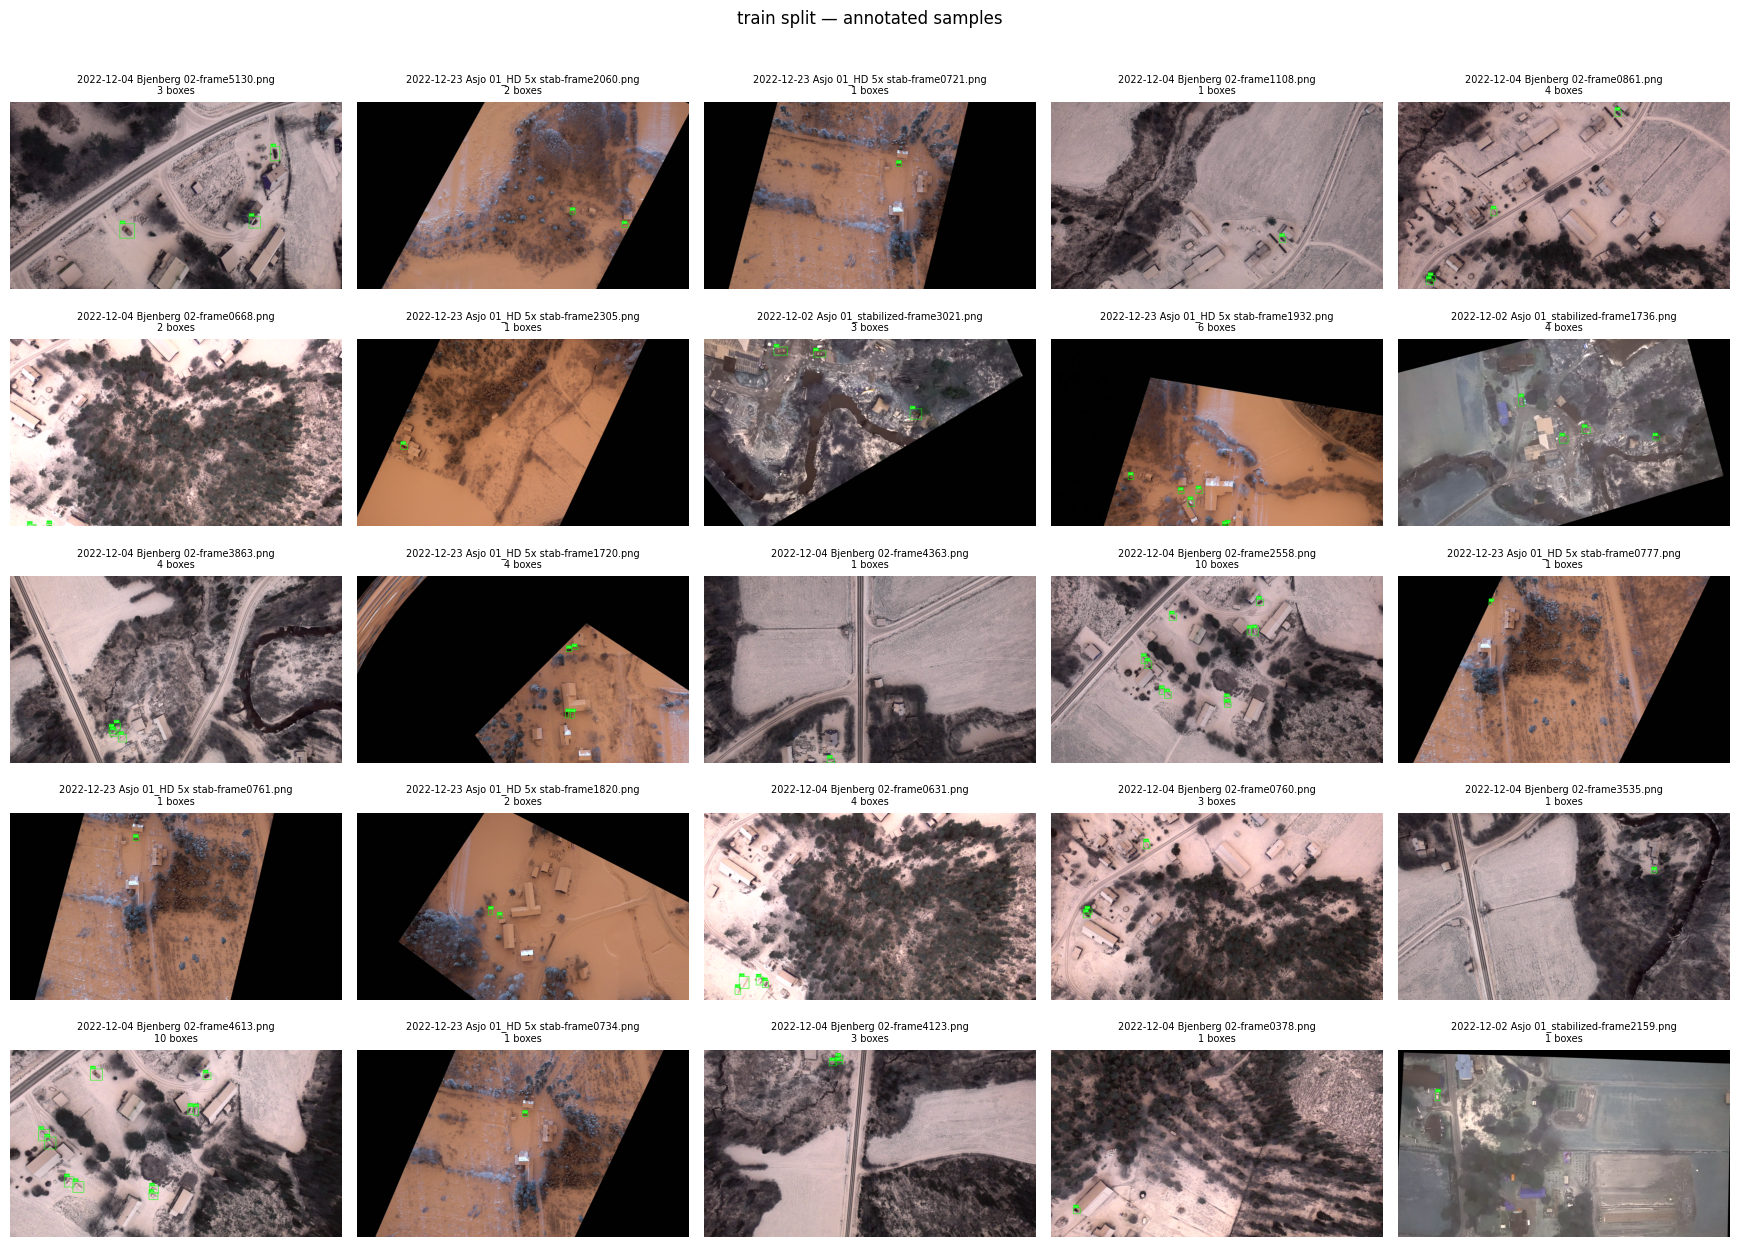

In [4]:

# -- EDA - Step 2: Visualise annotated samples --------------------------------
from eda.visualizer import plot_annotated_samples

fig = plot_annotated_samples(train_split, n=25, cols=5, seed=42)
fig.savefig(FIGURES / "eda_annotated_samples.png", bbox_inches="tight", dpi=120)
plt.show()


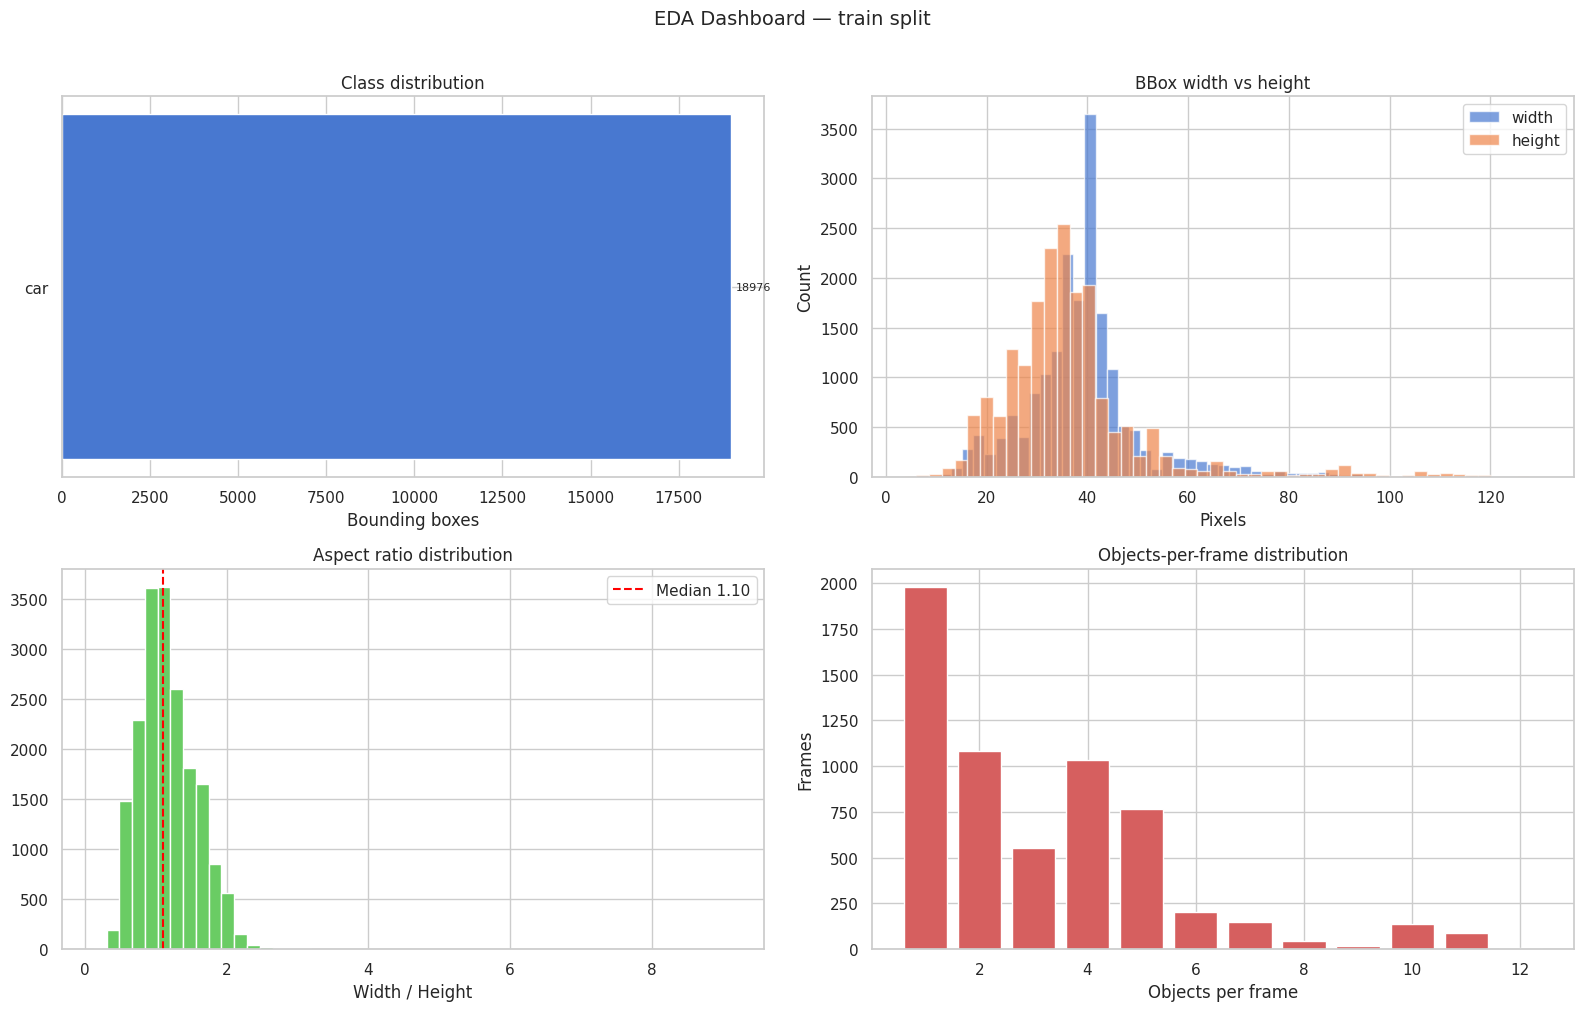

In [5]:

# -- EDA - Step 3: Distribution plots (all four in one dashboard) -------------
from eda.plots import plot_eda_dashboard

train_stats = compute_stats(train_split)

fig = plot_eda_dashboard(train_stats)
fig.savefig(FIGURES / "eda_dashboard_train.png", bbox_inches="tight", dpi=120)
plt.show()


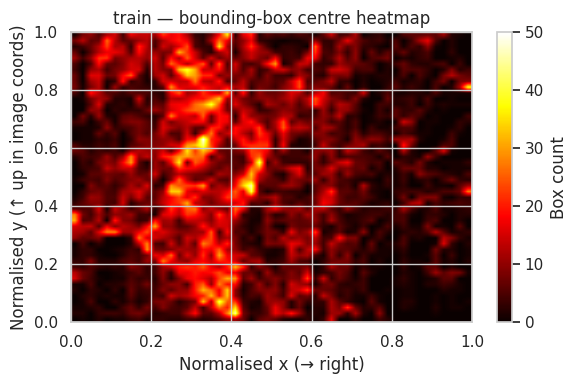

In [6]:

# -- EDA - Step 4: Bounding-box centre heatmap --------------------------------
from eda.visualizer import plot_bbox_heatmap

fig = plot_bbox_heatmap(train_stats)
fig.savefig(FIGURES / "eda_bbox_heatmap_train.png", bbox_inches="tight", dpi=120)
plt.show()


## 3. Dataset Preparation

No conversion needed – the NVD dataset is already in YOLO format.
`configs/data.yaml` points directly to the raw data and can be passed straight to ultralytics.

Run the cells below once to verify the dataset is correctly set up before training.

In [7]:

# -- Dataset Preparation - Step 2: Verify annotations visually ----------------
# Draws bounding boxes on a sample of images and saves them to results/figures/.
# Equivalent terminal command:
#   python scripts/verify_annotations.py --data-yaml configs/data_rec_sub.yaml --split train --n 10 --output results/figures/verify_train/

import subprocess
import sys

result = subprocess.run(
    [sys.executable, "scripts/verify_annotations.py",
     "--data-yaml", "configs/data_rec_sub.yaml",
     "--split", "train",
     "--n", "10",
     "--output", "results/figures/verify_train/"],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Saved 10 verified images to: results/figures/verify_train



## 4. Training

All training runs use the `scripts/training/` package:
- `training.yolo_trainer` — YOLO26s zero-shot eval + fine-tuning
- `training.detr_trainer` — RT-DETR fine-tuning + eval
- `training.frcnn_trainer` — Faster R-CNN fine-tuning + eval
- `training.sahi_eval` — SAHI evaluation (post-training)

**Strategy:** Train on pre-tiled 640×640 images (native resolution → cars at ~38px).  
**Augmentation ablation:** 3 variants × 3 models = 9 fine-tuning runs + 3 zero-shots.  
**Evaluation:** SAHI sliced inference on original full-resolution images.

Results accumulate in `results/model_comparison.csv`.

In [8]:
# --- Training imports & shared config ----------------------------------------
import sys
import shutil
from pathlib import Path

sys.path.insert(0, str(ROOT / "scripts"))

from training import (
    TrainingConfig,
    EvalMetrics,
    run_yolo_zero_shot_eval,
    run_yolo_fine_tuning,
    eval_yolo_checkpoint,
    eval_yolo_sahi,
    eval_detr_sahi,
    eval_frcnn_sahi,
    run_detr_zero_shot_eval,
    run_detr_fine_tuning,
    eval_detr_checkpoint,
    run_frcnn_zero_shot_eval,
    run_frcnn_fine_tuning,
    eval_frcnn_checkpoint,
    append_comparison_row,
)

# ─── DATA CONFIG ──────────────────────────────────────────────────────────────
# Original full-resolution data (for SAHI evaluation)
DATA_YAML = str(ROOT / "configs" / "data_rec_sub.yaml")

# Tiled dataset (for training — 640×640 tiles at native resolution)
DATA_TILED_YAML = str((ROOT / "configs" / "data_tiled.yaml").resolve())

# COCO JSON paths (for RT-DETR on tiled data)
TILED_DIR = ROOT / "data" / "tiled"
TILED_IMAGES = TILED_DIR / "images"
TILED_TRAIN_COCO = TILED_DIR / "train_coco.json"
TILED_VAL_COCO = TILED_DIR / "val_coco.json"

# Original COCO JSONs (for RT-DETR SAHI eval)
TRAIN_COCO_JSON = str(DATA_PROC / "annotations" / "instances_train.json")
VAL_COCO_JSON = str(DATA_PROC / "annotations" / "instances_val.json")
IMAGES_DIR = str(DATA_RAW / "images")

COMPARISON_CSV = str(RESULTS / "model_comparison.csv")

# Change to "cpu" if no GPU is available
DEVICE = "0"

print("Training imports OK")
print(f"Tiled data: {DATA_TILED_YAML}")
print(f"Eval data:  {DATA_YAML}")

Training imports OK
Tiled data: /home/jovyan/Advance_AI/Project/configs/data_tiled.yaml
Eval data:  /home/jovyan/Advance_AI/Project/configs/data_rec_sub.yaml


### 4.1 Dataset Preparation (Tiled + COCO)

Pre-slice all images into **640×640 overlapping tiles** at native resolution.
Cars remain at ~38px (vs ~20px when full image is resized to 1024).
Also generate COCO JSON annotations for the tiled dataset (required by RT-DETR).

Run once — subsequent training cells use the tiled dataset.

In [ ]:
# ── 4.1A Generate tiled dataset ───────────────────────────────────────────────
import subprocess, sys

tile_cmd = [
    sys.executable, "scripts/tile_dataset.py",
    "--tile-size", "640",
    "--overlap", "0.2",
    "--min-area", "0.3",
    "--splits", "train_rec_sub", "val_rec", "test",
]
result = subprocess.run(tile_cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

# ── 4.1B Generate COCO JSON for tiled dataset (RT-DETR) ──────────────────────
from scripts.prepare_coco_format import convert_yolo_to_coco

if not TILED_TRAIN_COCO.exists():
    convert_yolo_to_coco(
        images_dir=TILED_IMAGES,
        labels_dir=TILED_DIR / "labels",
        split_file=TILED_DIR / "train_rec_sub.txt",
        output_json=TILED_TRAIN_COCO,
        categories=[{"id": 0, "name": "car"}],
    )
    print(f"Created {TILED_TRAIN_COCO}")

if not TILED_VAL_COCO.exists():
    convert_yolo_to_coco(
        images_dir=TILED_IMAGES,
        labels_dir=TILED_DIR / "labels",
        split_file=TILED_DIR / "val_rec.txt",
        output_json=TILED_VAL_COCO,
        categories=[{"id": 0, "name": "car"}],
    )
    print(f"Created {TILED_VAL_COCO}")

# ── 4.1C Generate COCO JSON for original data (SAHI evaluation) ──────────────
result = subprocess.run(
    [sys.executable, "scripts/prepare_coco_format.py",
     "--data-yaml", DATA_YAML,
     "--output", str(DATA_PROC)],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
else:
    print("All dataset preparations complete.")

In [ ]:
# ── 4.1D Visualise tiling: original image → tiles ────────────────────────────
# Show how one full-resolution image is split into overlapping 640×640 tiles.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np
from pathlib import Path

# Pick a sample image from the training set
split_file = ROOT / "data" / "raw" / "train_rec_sub.txt"
with open(split_file) as f:
    sample_img_path = Path(f.readline().strip())

# Load full image
if not sample_img_path.is_absolute():
    sample_img_path = ROOT / "data" / "raw" / sample_img_path
img = Image.open(sample_img_path)
img_w, img_h = img.size

# Compute tile positions (same logic as tile_dataset.py)
TILE_SIZE = 640
OVERLAP = 0.2
stride = int(TILE_SIZE * (1 - OVERLAP))

positions = []
for y in range(0, img_h, stride):
    for x in range(0, img_w, stride):
        x = min(x, max(0, img_w - TILE_SIZE))
        y = min(y, max(0, img_h - TILE_SIZE))
        positions.append((x, y))
positions = list(set(positions))
positions.sort(key=lambda p: (p[1], p[0]))

print(f"Image: {sample_img_path.name} ({img_w}×{img_h})")
print(f"Tile size: {TILE_SIZE}×{TILE_SIZE}, overlap: {OVERLAP*100:.0f}%, stride: {stride}")
print(f"Number of tiles: {len(positions)}")

# --- Plot 1: Full image with tile grid overlay ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(img)
axes[0].set_title(f"Original image ({img_w}×{img_h}) with tile grid", fontsize=11)
colors = plt.cm.tab20(np.linspace(0, 1, len(positions)))
for i, (tx, ty) in enumerate(positions):
    rect = mpatches.Rectangle(
        (tx, ty), TILE_SIZE, TILE_SIZE,
        linewidth=1.2, edgecolor=colors[i], facecolor='none', linestyle='--'
    )
    axes[0].add_patch(rect)
axes[0].set_xlim(0, img_w)
axes[0].set_ylim(img_h, 0)
axes[0].axis('off')

# --- Plot 2: Show a few extracted tiles ---
n_show = min(6, len(positions))
axes[1].axis('off')
axes[1].set_title(f"First {n_show} extracted tiles ({TILE_SIZE}×{TILE_SIZE})", fontsize=11)
fig_tiles, ax_tiles = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    ax_tiles = [ax_tiles]

for i in range(n_show):
    tx, ty = positions[i]
    tile = img.crop((tx, ty, tx + TILE_SIZE, ty + TILE_SIZE))
    ax_tiles[i].imshow(tile)
    ax_tiles[i].set_title(f"Tile {i+1}\n({tx},{ty})", fontsize=9)
    ax_tiles[i].axis('off')

plt.tight_layout()
plt.show()
print(f"\n✓ Each tile preserves native resolution — cars remain at ~38px instead of ~20px after resize.")

### 4.2 YOLO26s

**YOLO26** (Jan 2026) — designed for small-object detection:
- ProgLoss + STAL loss functions for small-object recognition in aerial imagery
- End-to-end NMS-free inference
- MuSGD optimizer (hybrid SGD + Muon)
- 10M params, 22.8 GFLOPs

Training runs:
| Variant | Augmentation | Run name |
|---------|-------------|----------|
| 4.2A | Zero-shot (COCO pretrained) | — |
| 4.2B | Tiled, no aug | `yolo26s_nvd` |
| 4.2C | Tiled + full (weather+sensor) | `yolo26s_full` |
| 4.2D | Tiled + full_geo (geometry+weather+sensor) | `yolo26s_full_geo` |

In [9]:
# ── 4.2A YOLO26s Zero-shot baseline ────────────────────────────────────────────
# COCO-pretrained YOLO26s on NVD val set — no fine-tuning.
baseline_yolo26 = run_yolo_zero_shot_eval(
    model_name="yolo26s.pt",
    data_yaml=DATA_YAML,
    split="val",
    device=DEVICE,
)
append_comparison_row(baseline_yolo26, COMPARISON_CSV)

print(f"mAP@0.5     : {baseline_yolo26.map50:.4f}")
print(f"mAP@0.5:0.95: {baseline_yolo26.map50_95:.4f}")
print(f"Precision   : {baseline_yolo26.precision:.4f}")
print(f"Recall      : {baseline_yolo26.recall:.4f}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: deeplab15group (deeplab15group-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Ultralytics 8.4.54 🚀 Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
YOLO26s summary (fused): 122 layers, 9,496,140 parameters, 0 gradients, 20.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1420.0±898.8 MB/s, size: 2964.2 KB)
val: Scanning /home/jovyan/Advance_AI/Project/data/raw/labels.cache... 1203 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1203/1203 144.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 76/76 5.5it/s 13.7s0.1s
                   all       1203       4168     0.0324     0.0751    0.00265   0.000723
                person       1203       4168     0.0324     0.0751    0.00265   0.000723
Speed: 0.6ms preprocess, 2.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /runs/detect/val


eval/fps,▁
eval/map50,▁
eval/map50_95,▁
eval/precision,▁
eval/recall,▁
eval/fps,358.4
eval/map50,0.00265
eval/map50_95,0.00072
eval/precision,0.03245
eval/recall,0.0751


[results_writer] Appended row for 'yolo26s' → /home/jovyan/Advance_AI/Project/results/model_comparison.csv
mAP@0.5     : 0.0026
mAP@0.5:0.95: 0.0007
Precision   : 0.0324
Recall      : 0.0751


#### 4.2B YOLO26s Fine-tune (tiled, no augmentation)

In [ ]:
# ── 4.2B YOLO26s fine-tune on tiled dataset (no augmentation)
yolo26_config = TrainingConfig(
    model_name="/home/jovyan/Advance_AI/Project/yolo26s-p2.yaml",
    pretrained_weights="yolo26s.pt",
    data_yaml=DATA_TILED_YAML,
    epochs=200,
    batch=16,
    imgsz=640,
    lr0=0.0005,
    lrf=0.01,
    cos_lr=True,
    weight_decay=0.0005,
    warmup_epochs=3.0,
    nbs=64,
    freeze=None,
    device=DEVICE,
    patience=50,
    optimizer="AdamW",   # ← forces AdamW, bypasses MuSGD default
    mosaic=1.0,
    close_mosaic=20,
    mixup=0.1,
    copy_paste=0.2,
    scale=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    output_dir=str((MODELS_DIR / "yolo26").resolve()),
    run_name="yolo26s_p2_nvd",
)

yolo26_best = run_yolo_fine_tuning(yolo26_config, aug_variant="none")
yolo26_dest = MODELS_DIR / "yolo26s_nvd_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(str(yolo26_best), yolo26_dest)
print(f"Best checkpoint → {yolo26_dest}")

Transferred 360/902 items from pretrained weights
[INFO] Loaded pretrained weights from yolo26s.pt
Ultralytics 8.4.54 🚀 Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/jovyan/Advance_AI/Project/configs/data_tiled.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/home/jovyan/Advance_AI

#### 4.2C YOLO26s Fine-tune (tiled + full augmentation)

Full pipeline: `RandomSnow` + `RandomFog` + `RandomBrightnessContrast` + `GaussNoise` + `MotionBlur`

In [ ]:
# ── 4.2C YOLO26s fine-tune (tiled + full augmentation) ─────────────────────────
yolo26_full_config = TrainingConfig(
    model_name="/home/jovyan/Advance_AI/Project/yolo26s-p2.yaml",
    pretrained_weights="yolo26s.pt",
    data_yaml=DATA_TILED_YAML,
    epochs=200,
    batch=26,
    imgsz=640,
    lr0=0.0005,
    lrf=0.01,
    weight_decay=0.0005,  # increase from hardcoded 1e-4
    cos_lr=True,
    optimizer="AdamW",   # ← forces AdamW, bypasses MuSGD default
    warmup_epochs=3.0,
    nbs=64,
    freeze=None,
    device=DEVICE,
    patience=50,
    mosaic=1,
    close_mosaic=10,
    mixup=0.0,
    copy_paste=0.1,
    scale=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    output_dir=str((MODELS_DIR / "yolo26").resolve()),
    run_name="yolo26s_full",
)

yolo26_full_best = run_yolo_fine_tuning(yolo26_full_config, aug_variant="full")
yolo26_dest = MODELS_DIR / "yolo26s_p2_nvd_best.pt"
shutil.copy2(str(yolo26_full_best), yolo26_full_dest)
print(f"Best checkpoint → {yolo26_full_dest}")

#### 4.2D YOLO26s Fine-tune (tiled + full_geo augmentation)

Full+Geo pipeline: `HorizontalFlip` + `ShiftScaleRotate` + weather + sensor degradation

In [ ]:
# ── 4.2D YOLO26s fine-tune (tiled + full_geo augmentation) ─────────────────────
yolo26_fullgeo_config = TrainingConfig(
    model_name="/home/jovyan/Advance_AI/Project/yolo26s-p2.yaml",
    pretrained_weights="yolo26s.pt",
    data_yaml=DATA_TILED_YAML,
    epochs=200,
    batch=8,
    imgsz=640,
    lr0=0.0005,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    weight_decay=0.0005,  # increase from hardcoded 1e-4
    nbs=64,
    freeze=None,
    device=DEVICE,
    patience=50,
    mosaic=0.0,
    close_mosaic=0,
    mixup=0.0,
    copy_paste=0.1,
    scale=0.2,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    output_dir=str((MODELS_DIR / "yolo26").resolve()),
    run_name="yolo26s_full_geo",
)

yolo26_fullgeo_best = run_yolo_fine_tuning(yolo26_fullgeo_config, aug_variant="full_geo")
yolo26_fullgeo_dest = MODELS_DIR / "yolo26s_full_geo_best.pt"
shutil.copy2(str(yolo26_fullgeo_best), yolo26_fullgeo_dest)
print(f"Best checkpoint → {yolo26_fullgeo_dest}")

### 4.3 RT-DETR

**RT-DETR** (PekingU/rtdetr_r50vd) — Real-Time DEtection TRansformer:
- Transformer encoder with global attention
- Efficient hybrid encoder design
- No NMS post-processing needed

Training runs:
| Variant | Augmentation | Run name |
|---------|-------------|----------|
| 4.3A | Zero-shot (COCO pretrained) | — |
| 4.3B | Tiled, no aug | `rtdetr_nvd` |
| 4.3C | Tiled + full (weather+sensor) | `rtdetr_full` |
| 4.3D | Tiled + full_geo (geometry+weather+sensor) | `rtdetr_full_geo` |

#### 4.3A RT-DETR Zero-shot baseline

In [ ]:
# ── 4.3A RT-DETR Zero-shot baseline ────────────────────────────────────────────
rtdetr_zs = run_detr_zero_shot_eval(
    val_json=VAL_COCO_JSON,
    images_dir=IMAGES_DIR,
    model_name="PekingU/rtdetr_r50vd",
    split="val",
    device_str=DEVICE,
)
append_comparison_row(rtdetr_zs, COMPARISON_CSV)

print(f"mAP@0.5     : {rtdetr_zs.map50:.4f}")
print(f"mAP@0.5:0.95: {rtdetr_zs.map50_95:.4f}")
print(f"Precision   : {rtdetr_zs.precision:.4f}")
print(f"Recall      : {rtdetr_zs.recall:.4f}")

#### 4.3B RT-DETR Fine-tune (tiled, no augmentation)

In [ ]:
# ── 4.3B RT-DETR fine-tune on tiled dataset (no augmentation) ──────────────────
rtdetr_config = TrainingConfig(
    model_name="PekingU/rtdetr_r101vd",
    data_yaml="",
    epochs=200,
    batch=8,
    imgsz=640,
    lr0=1e-4,
    weight_decay=0.0005,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "rtdetr").resolve()),
    run_name="rtdetr_nvd",
)

rtdetr_best_dir = run_detr_fine_tuning(
    rtdetr_config,
    train_json=str(TILED_TRAIN_COCO),
    val_json=str(TILED_VAL_COCO),
    images_dir=str(TILED_IMAGES),
    aug_variant="none",
)
print(f"Best checkpoint → {rtdetr_best_dir}")

#### 4.3C RT-DETR Fine-tune (tiled + full augmentation)

In [ ]:
# ── 4.3C RT-DETR fine-tune (tiled + full augmentation) ─────────────────────────
rtdetr_full_config = TrainingConfig(
    model_name="PekingU/rtdetr_r101vd",
    data_yaml="",
    epochs=200,
    batch=8,
    imgsz=640,
    lr0=1e-4,
    weight_decay=0.0005,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "rtdetr").resolve()),
    run_name="rtdetr_full",
)

rtdetr_full_dir = run_detr_fine_tuning(
    rtdetr_full_config,
    train_json=str(TILED_TRAIN_COCO),
    val_json=str(TILED_VAL_COCO),
    images_dir=str(TILED_IMAGES),
    aug_variant="full",
)
print(f"Best checkpoint → {rtdetr_full_dir}")

#### 4.3D RT-DETR Fine-tune (tiled + full_geo augmentation)

In [ ]:
# ── 4.3D RT-DETR fine-tune (tiled + full_geo augmentation) ─────────────────────
rtdetr_fullgeo_config = TrainingConfig(
    model_name="PekingU/rtdetr_r101vd",
    data_yaml="",
    epochs=200,
    batch=8,
    imgsz=640,
    lr0=1e-4,
    weight_decay=0.0005,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "rtdetr").resolve()),
    run_name="rtdetr_full_geo",
)

rtdetr_fullgeo_dir = run_detr_fine_tuning(
    rtdetr_fullgeo_config,
    train_json=str(TILED_TRAIN_COCO),
    val_json=str(TILED_VAL_COCO),
    images_dir=str(TILED_IMAGES),
    aug_variant="full_geo",
)
print(f"Best checkpoint → {rtdetr_fullgeo_dir}")

### 4.4 Faster R-CNN

**Faster R-CNN** (fasterrcnn_resnet50_fpn) — classic two-stage detector:
- Region Proposal Network (RPN) + FPN multi-scale detection
- Torchvision implementation
- Good baseline for comparison with single-stage detectors

Training runs:
| Variant | Augmentation | Run name |
|---------|-------------|----------|
| 4.4A | Zero-shot (COCO pretrained) | — |
| 4.4B | Tiled, no aug | `frcnn_nvd` |
| 4.4C | Tiled + full (weather+sensor) | `frcnn_full` |
| 4.4D | Tiled + full_geo (geometry+weather+sensor) | `frcnn_full_geo` |

#### 4.4A Faster R-CNN Zero-shot baseline

In [ ]:
# ── 4.4A Faster R-CNN Zero-shot baseline ───────────────────────────────────────
frcnn_zs = run_frcnn_zero_shot_eval(
    data_yaml=DATA_YAML,
    split="val",
    device_str=DEVICE,
)
append_comparison_row(frcnn_zs, COMPARISON_CSV)

print(f"mAP@0.5     : {frcnn_zs.map50:.4f}")
print(f"mAP@0.5:0.95: {frcnn_zs.map50_95:.4f}")
print(f"Precision   : {frcnn_zs.precision:.4f}")
print(f"Recall      : {frcnn_zs.recall:.4f}")

#### 4.4B Faster R-CNN Fine-tune (tiled, no augmentation)

In [ ]:
frcnn_config = TrainingConfig(
    model_name="fasterrcnn_resnet101_fpn",  # upgraded backbone
    data_yaml=DATA_TILED_YAML,
    epochs=200,
    batch=8,
    imgsz=640,
    lr0=1e-4,              # lowered from 0.001
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    weight_decay=0.0005,   # added
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "frcnn").resolve()),
    run_name="frcnn_nvd",
)
frcnn_best = run_frcnn_fine_tuning(frcnn_config, data_yaml=DATA_TILED_YAML, aug_variant="none")
frcnn_dest = MODELS_DIR / "frcnn_nvd_best.pt"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(frcnn_best, frcnn_dest)
print(f"Best checkpoint → {frcnn_dest}")

#### 4.4C Faster R-CNN Fine-tune (tiled + full augmentation)

In [ ]:
# ── 4.4C Faster R-CNN fine-tune (tiled + full augmentation) ────────────────────
frcnn_full_config = TrainingConfig(
    model_name="fasterrcnn_resnet101_fpn",  # upgraded backbone
    data_yaml=DATA_TILED_YAML,
    epochs=200,
    batch=8,
    imgsz=640,
    lr0=1e-4, 
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    weight_decay=0.0005,   # added
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "frcnn").resolve()),
    run_name="frcnn_full",
)

frcnn_full_best = run_frcnn_fine_tuning(frcnn_full_config, data_yaml=DATA_TILED_YAML, aug_variant="full")
frcnn_full_dest = MODELS_DIR / "frcnn_full_best.pt"
shutil.copy2(frcnn_full_best, frcnn_full_dest)
print(f"Best checkpoint → {frcnn_full_dest}")

#### 4.4D Faster R-CNN Fine-tune (tiled + full_geo augmentation)

In [ ]:
# ── 4.4D Faster R-CNN fine-tune (tiled + full_geo augmentation) ────────────────
frcnn_fullgeo_config = TrainingConfig(
    model_name="fasterrcnn_resnet101_fpn",  # upgraded backbone
    data_yaml=DATA_TILED_YAML,
    epochs=200,
    batch=8,
    imgsz=640,
    lr0=1e-4, 
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5.0,
    weight_decay=0.0005,   # added
    freeze=None,
    device=DEVICE,
    patience=50,
    output_dir=str((MODELS_DIR / "frcnn").resolve()),
    run_name="frcnn_full_geo",
)

frcnn_fullgeo_best = run_frcnn_fine_tuning(frcnn_fullgeo_config, data_yaml=DATA_TILED_YAML, aug_variant="full_geo")
frcnn_fullgeo_dest = MODELS_DIR / "frcnn_full_geo_best.pt"
shutil.copy2(frcnn_fullgeo_best, frcnn_fullgeo_dest)
print(f"Best checkpoint → {frcnn_fullgeo_dest}")

### 4.5 Results Comparison

Load `results/model_comparison.csv` and display all training results side by side.

In [ ]:
# ── 4.5 Results comparison table ───────────────────────────────────────────────
import pandas as pd

comparison_path = Path(COMPARISON_CSV)
if comparison_path.exists():
    df = pd.read_csv(comparison_path)
    numeric_cols = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "FPS"]
    display(
        df.style
          .highlight_max(subset=numeric_cols, color="lightgreen")
          .format({c: "{:.4f}" for c in numeric_cols if c != "FPS"})
          .format({"FPS": "{:.1f}"})
          .set_caption("Training Results — All Models (val set)")
    )
else:
    print(f"No comparison CSV yet at {comparison_path}. Run the training cells first.")

## 5. Evaluation (SAHI)

**Sliced Aided Hyper Inference** — slices full-resolution images into overlapping
640×640 tiles, runs detection on each tile, then merges predictions with NMS.

- Applied post-training on the **original full-resolution images** (not tiled dataset)
- Dramatically improves recall for small objects (~38px cars at 1920×1080)
- Evaluated on **val** set for all models, then **test** set for the best model

> Requires: `pip install sahi`

In [ ]:
# ── 5.1 SAHI evaluation — all models on val set ───────────────────────────────
# SAHI is inference-time only. Evaluates on original full-resolution images.

# ── YOLO26s checkpoints ──────────────────────────────────────────────────────
_yolo_sahi_configs = [
    ("yolo26s_nvd_best.pt",      "YOLO26s · no aug (SAHI)"),
    ("yolo26s_full_best.pt",     "YOLO26s · full aug (SAHI)"),
    ("yolo26s_full_geo_best.pt", "YOLO26s · full_geo aug (SAHI)"),
]

# ── Faster R-CNN checkpoints ─────────────────────────────────────────────────
_frcnn_sahi_configs = [
    ("frcnn_nvd_best.pt",      "FRCNN · no aug (SAHI)"),
    ("frcnn_full_best.pt",     "FRCNN · full aug (SAHI)"),
    ("frcnn_full_geo_best.pt", "FRCNN · full_geo aug (SAHI)"),
]

# ── RT-DETR checkpoints ──────────────────────────────────────────────────────
_detr_sahi_configs = [
    (MODELS_DIR / "rtdetr" / "rtdetr_nvd" / "best_checkpoint",      "RT-DETR · no aug (SAHI)"),
    (MODELS_DIR / "rtdetr" / "rtdetr_full" / "best_checkpoint",     "RT-DETR · full aug (SAHI)"),
    (MODELS_DIR / "rtdetr" / "rtdetr_full_geo" / "best_checkpoint", "RT-DETR · full_geo aug (SAHI)"),
]

sahi_results = {}

# YOLO26s SAHI
for ckpt_name, label in _yolo_sahi_configs:
    ckpt_path = MODELS_DIR / ckpt_name
    if not ckpt_path.exists():
        print(f"  [SKIP] {ckpt_name} not found")
        continue
    metrics = eval_yolo_sahi(
        weights=str(ckpt_path),
        data_yaml=DATA_YAML,
        split="val",
        device=DEVICE,
        slice_height=640,
        slice_width=640,
        overlap_ratio=0.2,
        model_label=label,
    )
    append_comparison_row(metrics, COMPARISON_CSV)
    sahi_results[label] = metrics

# Faster R-CNN SAHI
for ckpt_name, label in _frcnn_sahi_configs:
    ckpt_path = MODELS_DIR / ckpt_name
    if not ckpt_path.exists():
        print(f"  [SKIP] {ckpt_name} not found")
        continue
    metrics = eval_frcnn_sahi(
        weights=str(ckpt_path),
        data_yaml=DATA_YAML,
        split="val",
        device=DEVICE,
        slice_height=640,
        slice_width=640,
        overlap_ratio=0.2,
        model_label=label,
    )
    append_comparison_row(metrics, COMPARISON_CSV)
    sahi_results[label] = metrics

# RT-DETR SAHI
for ckpt_dir, label in _detr_sahi_configs:
    if not Path(ckpt_dir).exists():
        print(f"  [SKIP] {ckpt_dir} not found")
        continue
    metrics = eval_detr_sahi(
        checkpoint_dir=str(ckpt_dir),
        val_json=VAL_COCO_JSON,
        images_dir=IMAGES_DIR,
        split="val",
        device=DEVICE,
        slice_height=640,
        slice_width=640,
        overlap_ratio=0.2,
        model_label=label,
    )
    append_comparison_row(metrics, COMPARISON_CSV)
    sahi_results[label] = metrics

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SAHI evaluation results (val set, 640×640 tiles, 20% overlap)")
print("=" * 60)
for label, m in sahi_results.items():
    print(f"\n  {label}:")
    print(f"    mAP@0.5: {m.map50:.4f}  |  mAP@0.5:0.95: {m.map50_95:.4f}")
    print(f"    Precision: {m.precision:.4f}  |  Recall: {m.recall:.4f}")

### 5.2 SAHI on Test Set (Best Model)

Run SAHI on the held-out test set for the best-performing model from 5.1.

In [ ]:
# ── 5.2 SAHI on test set — best model ─────────────────────────────────────────
if sahi_results:
    best_sahi_label = max(sahi_results, key=lambda k: sahi_results[k].map50)
    print(f"Best SAHI model (val): {best_sahi_label}")
    print(f"  val mAP@0.5: {sahi_results[best_sahi_label].map50:.4f}")
    print("\nRunning SAHI on TEST set...")

    # Determine model type and run test-set SAHI
    if "YOLO" in best_sahi_label:
        best_ckpt = next(c for c, l in _yolo_sahi_configs if l == best_sahi_label)
        sahi_test = eval_yolo_sahi(
            weights=str(MODELS_DIR / best_ckpt),
            data_yaml=DATA_YAML,
            split="test",
            device=DEVICE,
            slice_height=640, slice_width=640, overlap_ratio=0.2,
            model_label=f"{best_sahi_label} [test]",
        )
    elif "FRCNN" in best_sahi_label:
        best_ckpt = next(c for c, l in _frcnn_sahi_configs if l == best_sahi_label)
        sahi_test = eval_frcnn_sahi(
            weights=str(MODELS_DIR / best_ckpt),
            data_yaml=DATA_YAML,
            split="test",
            device=DEVICE,
            slice_height=640, slice_width=640, overlap_ratio=0.2,
            model_label=f"{best_sahi_label} [test]",
        )
    else:  # RT-DETR
        best_ckpt_dir = next(d for d, l in _detr_sahi_configs if l == best_sahi_label)
        sahi_test = eval_detr_sahi(
            checkpoint_dir=str(best_ckpt_dir),
            val_json=VAL_COCO_JSON,  # test JSON would be needed; using val as proxy
            images_dir=IMAGES_DIR,
            split="test",
            device=DEVICE,
            slice_height=640, slice_width=640, overlap_ratio=0.2,
            model_label=f"{best_sahi_label} [test]",
        )

    append_comparison_row(sahi_test, COMPARISON_CSV)
    print(f"\n  TEST-set SAHI results:")
    print(f"    mAP@0.5: {sahi_test.map50:.4f}  |  mAP@0.5:0.95: {sahi_test.map50_95:.4f}")
    print(f"    Precision: {sahi_test.precision:.4f}  |  Recall: {sahi_test.recall:.4f}")
else:
    print("No SAHI results available — run section 5.1 first.")

## 6. Error Analysis

Qualitative failure analysis on the **held-out test set** for all 9 trained models
(YOLO26s · RT-DETR · Faster R-CNN × none / full / full_geo augmentation).

Three failure categories are examined per model:

| Category | Definition |
|---|---|
| **False Negatives** | Cars present in the image that were not detected (IoU < 0.5 with every prediction) |
| **False Positives** | Predictions with no matching ground-truth car (IoU < 0.5 with every GT box) |
| **Poor Localisation** | Car detected but IoU with the ground truth falls in [0.3, 0.5) |

Confidence threshold applied before matching: **conf ≥ 0.3**.

- **6.1** — Build checkpoint map + run inference on test set
- **6.2** — Categorise errors per model
- **6.3** — Visualise failure grids

In [ ]:
# ── 6.1 Build checkpoint map & run inference ──────────────────────────────────
from analysis import collect_test_items, infer_all_models

# Checkpoint map for all 9 fine-tuned models
_CHECKPOINT_MAP = {
    "YOLO26s · no aug":       {"type": "yolo",  "imgsz": 640, "path": MODELS_DIR / "yolo26s_nvd_best.pt"},
    "YOLO26s · full aug":     {"type": "yolo",  "imgsz": 640, "path": MODELS_DIR / "yolo26s_full_best.pt"},
    "YOLO26s · full_geo aug": {"type": "yolo",  "imgsz": 640, "path": MODELS_DIR / "yolo26s_full_geo_best.pt"},
    "RT-DETR · no aug":       {"type": "detr",  "imgsz": 640, "path": (MODELS_DIR / "rtdetr" / "rtdetr_nvd" / "best_checkpoint").resolve()},
    "RT-DETR · full aug":     {"type": "detr",  "imgsz": 640, "path": (MODELS_DIR / "rtdetr" / "rtdetr_full" / "best_checkpoint").resolve()},
    "RT-DETR · full_geo aug": {"type": "detr",  "imgsz": 640, "path": (MODELS_DIR / "rtdetr" / "rtdetr_full_geo" / "best_checkpoint").resolve()},
    "FRCNN · no aug":         {"type": "frcnn", "imgsz": 640, "path": MODELS_DIR / "frcnn_nvd_best.pt"},
    "FRCNN · full aug":       {"type": "frcnn", "imgsz": 640, "path": MODELS_DIR / "frcnn_full_best.pt"},
    "FRCNN · full_geo aug":   {"type": "frcnn", "imgsz": 640, "path": MODELS_DIR / "frcnn_full_geo_best.pt"},
}

print(f"Checkpoint map ({len(_CHECKPOINT_MAP)} models):")
for name, info in _CHECKPOINT_MAP.items():
    status = "✓" if info["path"].exists() else "✗ MISSING"
    print(f"  {status}  {name}")

# Collect GT items from test split
_test_items = collect_test_items(test_split)
print(f"\nTest set: {len(_test_items)} images")

# Run inference on all models
_all_inferences = infer_all_models(_CHECKPOINT_MAP, _test_items, device_str=DEVICE)
present = sum(1 for v in _all_inferences.values() if v is not None)
print(f"Inference complete: {present}/{len(_CHECKPOINT_MAP)} models.")

In [ ]:

# ── 6.2  Categorise errors for every model ────────────────────────────────────
# Uses scripts/analysis/categoriser.py (SRP: IoU-matching & classification).
# Uses scripts/analysis/reporter.py    (SRP: summary table & CSV).

from analysis import categorise_all_models
from analysis.reporter import build_summary_df, save_summary_csv

_all_errors = categorise_all_models(_all_inferences)

df_errors = build_summary_df(_all_errors)
save_summary_csv(df_errors, RESULTS / "error_analysis_summary.csv")

# Style: green = fewest errors (best), red = most errors (worst)
_numeric_cols = ["False Negatives", "False Positives", "Poor Localisation"]
display(
    df_errors.style
    .highlight_min(subset=_numeric_cols, color="lightgreen")
    .highlight_max(subset=_numeric_cols, color="#ffcccc")
    .set_caption("Error Analysis — all 9 models  (test set · conf ≥ 0.3)")
)


In [ ]:

# ── 6.3  Visualise failure grids for all models ───────────────────────────────
# Uses scripts/analysis/reporter.py    (SRP: bar chart).
# Uses scripts/analysis/visualiser.py  (SRP: image rendering & grid export).

from analysis.reporter   import plot_error_bar_chart
from analysis.visualiser import save_all_grids

# Grouped bar chart — FN / FP / Poor per model
fig = plot_error_bar_chart(_all_errors, save_path=FIGURES / "error_analysis_summary.png")
plt.show()

# Failure grids — 9-panel crops for every error type, every model.
# Grids for BEST_MODEL are shown inline; all others are saved only.
print("\nSaving failure grids …")
save_all_grids(_all_errors, figures_dir=FIGURES, best_model=BEST_MODEL)
